# Safe-cracking scoring fairness

This notebook compares the existing leaderboard with a peer- and schedule-adjusted ranking. It treats `0.5` as an invalid or unreliable attempt rather than half a successful crack, and adjusts peer scores for whether each scoring team tends to be harsh or generous.

Cracking uses a regularised Rasch model: $\operatorname{logit}(P(\text{crack})) = \text{overall rate} + \text{attacker ability} - \text{safe difficulty}$. Peer scoring uses a regularised additive model: $\text{score} = \text{overall level} + \text{safe quality} + \text{rater generosity} + \text{noise}$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from analyse_scoring import analyse, write_outputs

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titleweight': 'bold', 'axes.labelsize': 10})

rows, attempts, diagnostics = analyse()
ranking = pd.DataFrame(rows).sort_values('adjusted_rank').reset_index(drop=True)
print(f"Loaded {diagnostics['team_count']} teams and {diagnostics['attempt_count']} recorded matchups.")

Loaded 18 teams and 162 recorded matchups.


## Data quality

Invalid records contain no dependable evidence about either team, so they are excluded from model fitting. The existing spreadsheet instead gives them a value of `0.5`.

In [2]:
quality = pd.DataFrame({
    'Measure': [
        'Teams', 'Recorded matchups', 'Valid outcomes', 'Invalid / unreliable',
        'Valid crack rate', 'Crack regularisation', 'Crack CV log loss', 'Crack baseline log loss',
        'Peer regularisation', 'Peer CV RMSE', 'Peer mean-only RMSE',
    ],
    'Value': [
        diagnostics['team_count'], diagnostics['attempt_count'], diagnostics['valid_count'],
        diagnostics['invalid_count'], f"{diagnostics['overall_valid_crack_rate']:.1%}",
        diagnostics['regularisation'],
        f"{diagnostics['cv_losses'][diagnostics['regularisation']]:.3f}",
        f"{diagnostics['baseline_log_loss']:.3f}",
        diagnostics['peer_regularisation'], f"{diagnostics['peer_cv_rmse']:.3f}",
        f"{diagnostics['peer_baseline_rmse']:.3f}",
    ],
})
display(quality.style.hide(axis='index'))

invalid_share = diagnostics['invalid_count'] / diagnostics['attempt_count']
display(Markdown(f"**{invalid_share:.1%} of recorded crack attempts are unreliable.** They are excluded rather than counted as half-successes."))

Measure,Value
Teams,18
Recorded matchups,162
Valid outcomes,123
Invalid / unreliable,39
Valid crack rate,55.3%
Crack regularisation,1.000000
Crack CV log loss,0.610
Crack baseline log loss,0.688
Peer regularisation,4.000000
Peer CV RMSE,0.144


**24.1% of recorded crack attempts are unreliable.** They are excluded rather than counted as half-successes.

## Adjusted leaderboard

The published weights remain unchanged: 45% judges, 20% peers, 25% cracking and 10% resistance. Only the two crack-derived components are adjusted for opponent difficulty.

In [3]:
leaderboard = ranking[[
    'adjusted_rank', 'current_rank', 'rank_change', 'code', 'team',
    'current_total', 'adjusted_total', 'valid_attacks', 'invalid_attacks'
]].rename(columns={
    'adjusted_rank': 'Fair rank', 'current_rank': 'Current rank', 'rank_change': 'Places gained',
    'code': 'Code', 'team': 'Team / safe', 'current_total': 'Current total',
    'adjusted_total': 'Fair total', 'valid_attacks': 'Valid attacks',
    'invalid_attacks': 'Invalid attacks',
})
display(leaderboard.style.format({'Current total': '{:.2f}', 'Fair total': '{:.2f}'}).hide(axis='index'))

Fair rank,Current rank,Places gained,Code,Team / safe,Current total,Fair total,Valid attacks,Invalid attacks
1,2,1,3A,3A Tonbridge: Cooke's Arcade,78.19,77.93,6,3
2,1,-1,1E,1E Simon Langton Grammar: Dead or Alive,79.54,76.85,6,3
3,3,0,1D,1D Dulwich: Rice to the Occasion,75.76,73.29,7,2
4,4,0,3F,3F Eltham: FZN,73.33,72.65,9,0
5,6,1,1B,1B Westminster: Operation Ovenbreak,69.17,67.53,6,3
6,5,-1,2B,2B Sevenoaks: The Oaks Heist,69.27,66.84,9,0
7,7,0,2A,2A St Paul's: Lableak,64.30,66.26,6,3
8,8,0,3C,3C HABS: The Maxwell Demon,64.22,62.84,7,2
9,9,0,3E,3E Eltham: MAXimum Security,60.01,60.52,6,3
10,12,2,2E,2E Emanuel: BlackHole,55.76,57.20,5,4


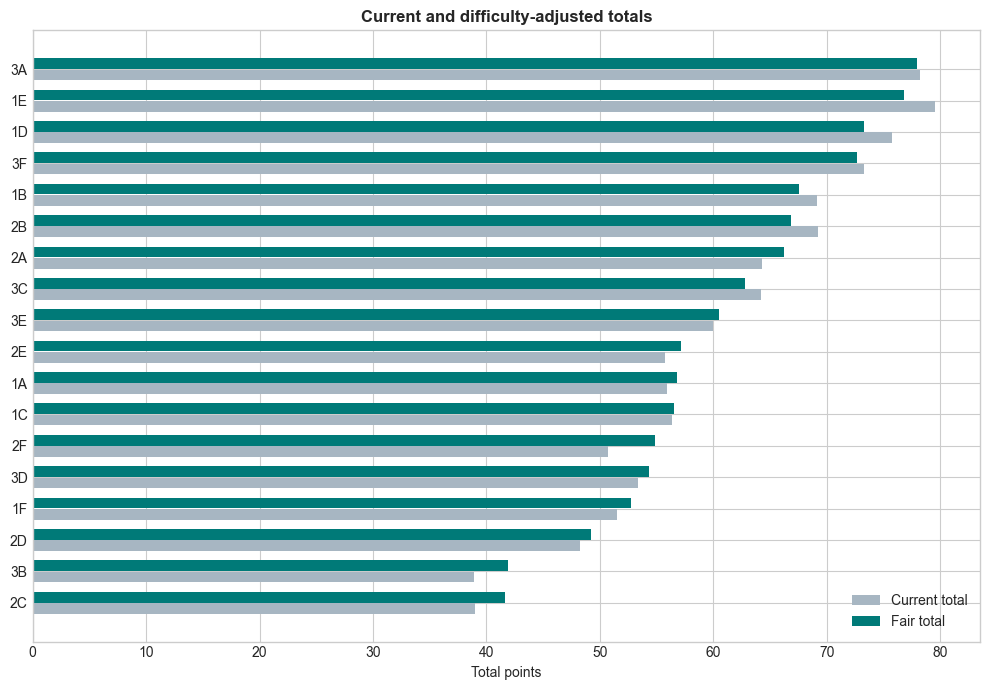

In [4]:
plot_data = ranking.sort_values('adjusted_total')
fig, ax = plt.subplots(figsize=(10, 7))
positions = np.arange(len(plot_data))
ax.barh(positions - 0.18, plot_data['current_total'], height=0.34, color='#A7B6C2', label='Current total')
ax.barh(positions + 0.18, plot_data['adjusted_total'], height=0.34, color='#007A78', label='Fair total')
ax.set(yticks=positions, yticklabels=plot_data['code'], xlabel='Total points', title='Current and difficulty-adjusted totals')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Was each cracking schedule equally difficult?

`Schedule easiness` is the modelled success rate an average team would expect against the safes allocated to that team. A higher value means an easier set of safes.

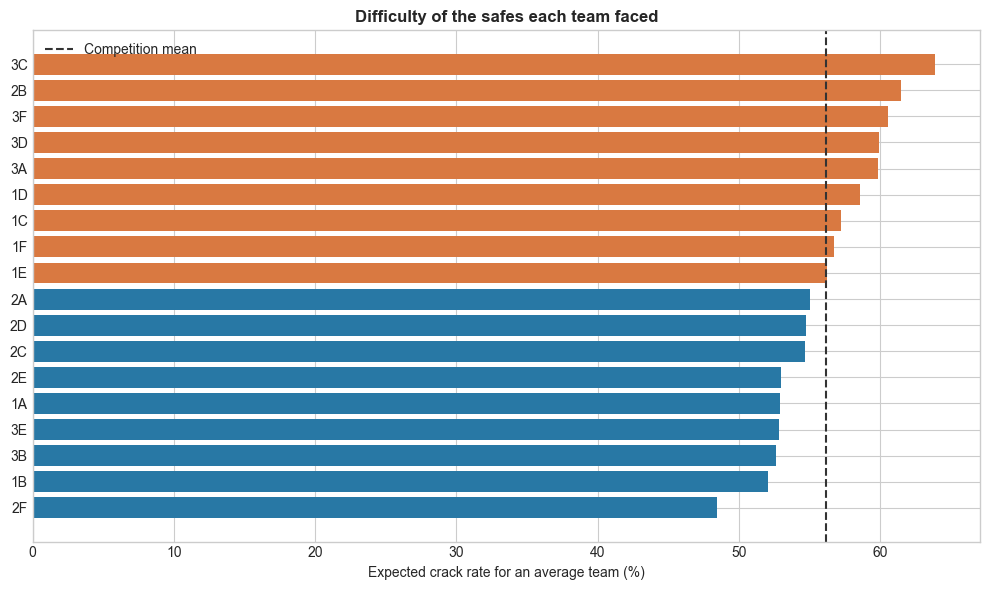

The estimated hardest schedule was **2F** (48.5%); the easiest was **3C** (63.9%).

In [5]:
schedule = ranking.sort_values('schedule_easiness')
fig, ax = plt.subplots(figsize=(10, 6))
colours = np.where(schedule['schedule_easiness'] > schedule['schedule_easiness'].mean(), '#D97941', '#2878A5')
ax.barh(schedule['code'], 100 * schedule['schedule_easiness'], color=colours)
ax.axvline(100 * schedule['schedule_easiness'].mean(), color='#333333', linestyle='--', label='Competition mean')
ax.set(xlabel='Expected crack rate for an average team (%)', ylabel='', title='Difficulty of the safes each team faced')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

hardest = schedule.iloc[0]
easiest = schedule.iloc[-1]
display(Markdown(
    f"The estimated hardest schedule was **{hardest['code']}** ({hardest['schedule_easiness']:.1%}); "
    f"the easiest was **{easiest['code']}** ({easiest['schedule_easiness']:.1%})."
))

## Are peer scorers equally harsh?

The peer model separates a safe's peer-rated quality from each team's tendency to award high or low marks. **Rater tendency** is measured in percentage points after accounting for which safes that team scored: negative means harsher than average; positive means more generous. Adjusted peer scores are shrunk toward the competition mean when evidence is limited.

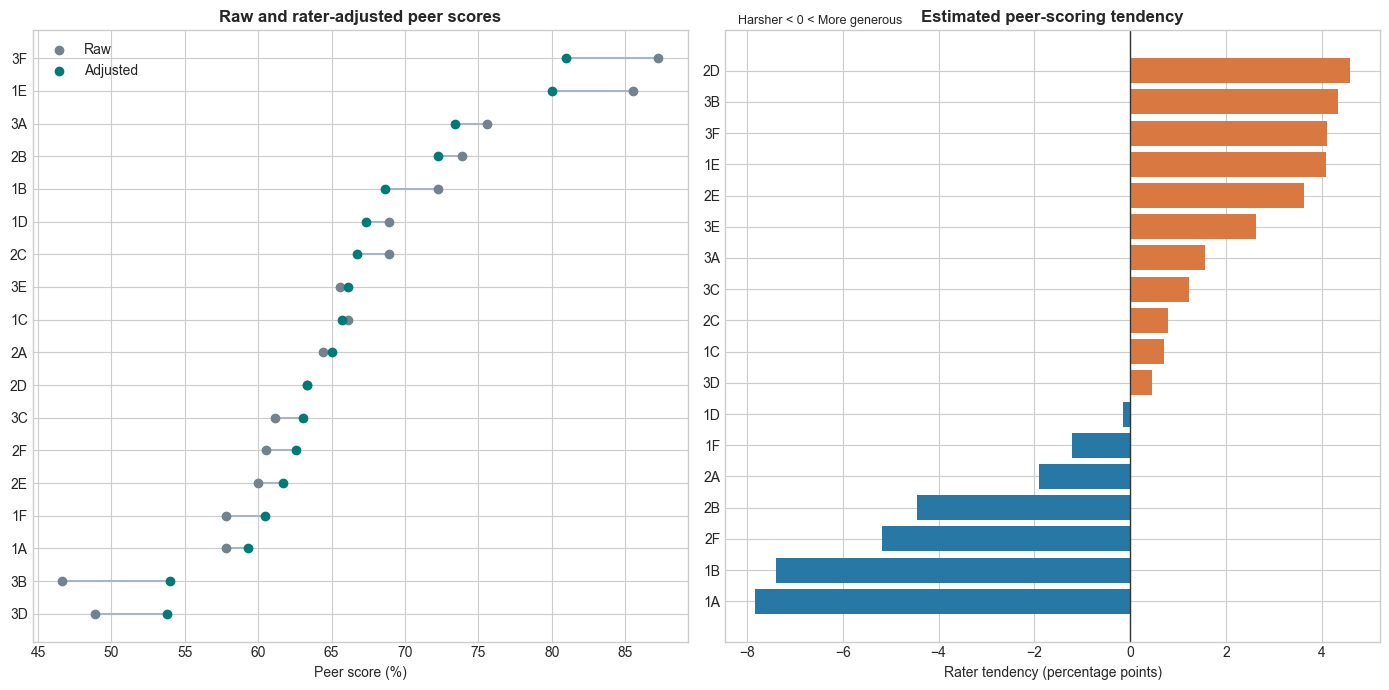

In [6]:
peer_view = ranking.sort_values('adjusted_peer')
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
positions = np.arange(len(peer_view))
raw_peer = 100 * peer_view['peer'].to_numpy()
adjusted_peer = 100 * peer_view['adjusted_peer'].to_numpy()
for position, raw, adjusted in zip(positions, raw_peer, adjusted_peer):
    axes[0].plot([raw, adjusted], [position, position], color='#A7B6C2', linewidth=1.5)
axes[0].scatter(raw_peer, positions, color='#70838F', label='Raw', zorder=3)
axes[0].scatter(adjusted_peer, positions, color='#007A78', label='Adjusted', zorder=3)
axes[0].set(yticks=positions, yticklabels=peer_view['code'], xlabel='Peer score (%)', title='Raw and rater-adjusted peer scores')
axes[0].legend(frameon=False)

rater_view = ranking.sort_values('peer_rater_effect')
rater_points = 100 * rater_view['peer_rater_effect']
colours = np.where(rater_points < 0, '#2878A5', '#D97941')
axes[1].barh(rater_view['code'], rater_points, color=colours)
axes[1].axvline(0, color='#333333', linewidth=1)
axes[1].set(xlabel='Rater tendency (percentage points)', title='Estimated peer-scoring tendency')
axes[1].text(0.02, 1.01, 'Harsher < 0 < More generous', transform=axes[1].transAxes, fontsize=9)
plt.tight_layout()
plt.show()

## How certain are the crack scores?

The points show each team's adjusted chance of cracking an average safe. Lines are approximate 95% model intervals from a Laplace approximation, conditional on the selected regularisation. Wide and overlapping intervals are a warning not to over-interpret small differences.

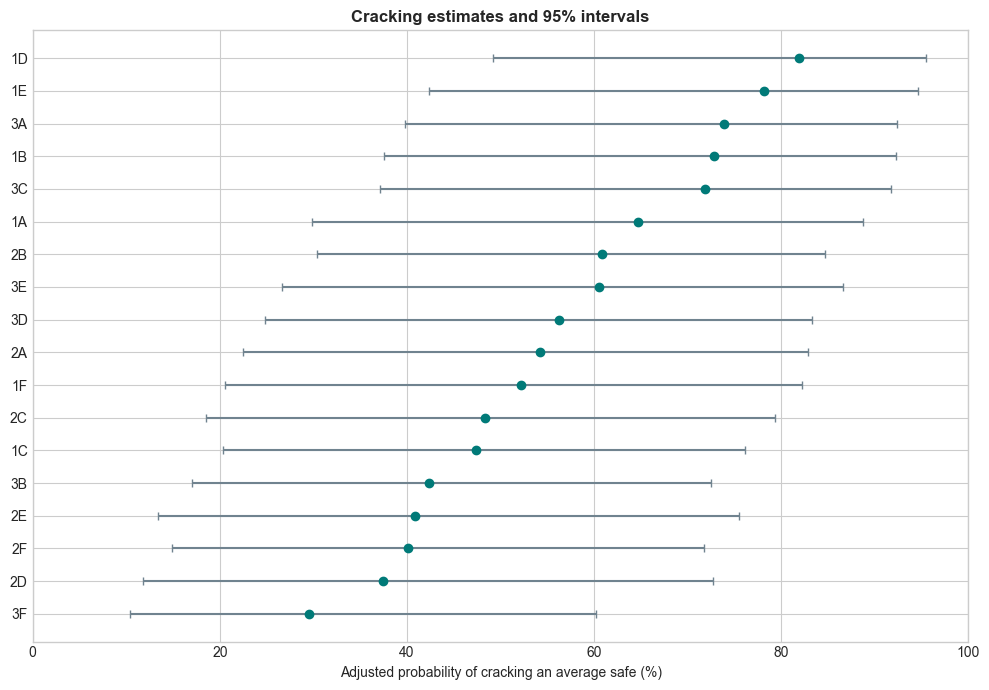

In [7]:
uncertainty = ranking.sort_values('adjusted_attack')
estimate = 100 * uncertainty['adjusted_attack'].to_numpy()
lower = 100 * uncertainty['attack_low'].to_numpy()
upper = 100 * uncertainty['attack_high'].to_numpy()
fig, ax = plt.subplots(figsize=(10, 7))
ax.errorbar(estimate, uncertainty['code'], xerr=[estimate - lower, upper - estimate], fmt='o', color='#007A78', ecolor='#70838F', capsize=3)
ax.set(xlabel='Adjusted probability of cracking an average safe (%)', ylabel='', title='Cracking estimates and 95% intervals')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

## Invalid-attempt burden

This view checks whether unreliable attempts were evenly distributed. Teams with fewer valid observations have less precise model estimates and are pulled more strongly toward the competition average.

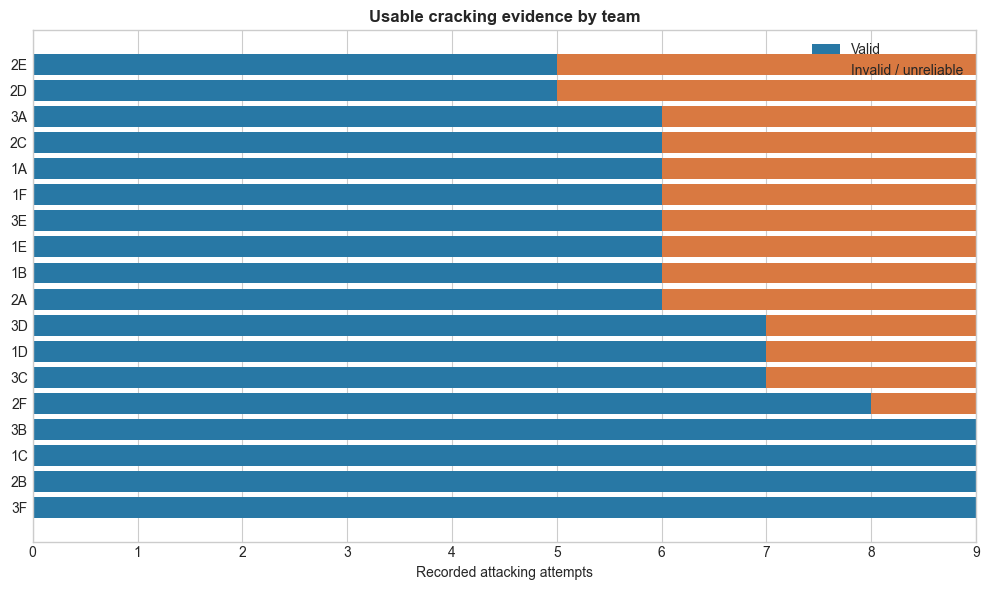

In [8]:
burden = ranking.sort_values('invalid_attacks')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(burden['code'], burden['valid_attacks'], color='#2878A5', label='Valid')
ax.barh(burden['code'], burden['invalid_attacks'], left=burden['valid_attacks'], color='#D97941', label='Invalid / unreliable')
ax.set(xlabel='Recorded attacking attempts', ylabel='', title='Usable cracking evidence by team')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Decision table for judges

This is the table to use when making the decision. **Raw total** is the initial spreadsheet score. The four component columns show their weighted contribution to the final score, so they add directly to **Fair score**: judges out of 45, adjusted peers out of 20, adjusted cracking out of 25, and adjusted resistance out of 10.

The model range covers conditional uncertainty in peer, cracking and resistance adjustments; judge marks are treated as fixed. Teams marked **Winner review** should be moderated together rather than separated by decimal places.

In [9]:
decision_table = ranking.copy()
decision_table['Judges /45'] = 100 * decision_table['judge'] * diagnostics['weights']['judge']
decision_table['Peers /20'] = 100 * decision_table['adjusted_peer'] * diagnostics['weights']['peer']
decision_table['Cracking /25'] = 100 * decision_table['adjusted_attack'] * diagnostics['weights']['attack']
decision_table['Resistance /10'] = 100 * decision_table['adjusted_resistance'] * diagnostics['weights']['resistance']
decision_table['Model range'] = decision_table.apply(
    lambda row: f"{row['adjusted_total_low']:.1f} - {row['adjusted_total_high']:.1f}", axis=1
)
decision_table['Status'] = np.select(
    [decision_table['adjusted_rank'].eq(1), decision_table['winner_review']],
    ['Provisional leader - moderate', 'Winner review'],
    default='Outside winner-review group',
)
decision_table = decision_table[[
    'adjusted_rank', 'code', 'team', 'current_total', 'Judges /45', 'Peers /20',
    'Cracking /25', 'Resistance /10', 'adjusted_total', 'Model range', 'Status',
]].rename(columns={
    'adjusted_rank': 'Fair rank', 'code': 'Code', 'team': 'Team / safe',
    'current_total': 'Raw total', 'adjusted_total': 'Fair score',
})

def highlight_decision_rows(row):
    if row['Status'].startswith('Provisional leader'):
        colour = 'background-color: #DCEFE8; font-weight: bold'
    elif row['Status'] == 'Winner review':
        colour = 'background-color: #FFF0D5'
    else:
        colour = ''
    return [colour] * len(row)

score_columns = ['Raw total', 'Judges /45', 'Peers /20', 'Cracking /25', 'Resistance /10', 'Fair score']
display(
    decision_table.style
    .format({column: '{:.2f}' for column in score_columns})
    .apply(highlight_decision_rows, axis=1)
    .hide(axis='index')
)

review_codes = ', '.join(ranking.loc[ranking['winner_review'], 'code'])
display(Markdown(
    f"**Recommendation:** treat **{review_codes}** as the winner-review group and moderate them "
    "using the published judging rubric."
))

Fair rank,Code,Team / safe,Raw total,Judges /45,Peers /20,Cracking /25,Resistance /10,Fair score,Model range,Status
1,3A,3A Tonbridge: Cooke's Arcade,78.19,37.80,14.68,18.47,6.98,77.93,70.4 - 85.4,Provisional leader - moderate
2,1E,1E Simon Langton Grammar: Dead or Alive,79.54,36.60,16.00,19.55,4.70,76.85,69.5 - 84.2,Winner review
3,1D,1D Dulwich: Rice to the Occasion,75.76,34.20,13.47,20.47,5.15,73.29,66.5 - 80.1,Winner review
4,3F,3F Eltham: FZN,73.33,42.00,16.19,7.37,7.08,72.65,65.4 - 79.9,Winner review
5,1B,1B Westminster: Operation Ovenbreak,69.17,30.00,13.72,18.21,5.59,67.53,59.6 - 75.5,Outside winner-review group
6,2B,2B Sevenoaks: The Oaks Heist,69.27,30.60,14.45,15.21,6.59,66.84,58.8 - 74.9,Outside winner-review group
7,2A,2A St Paul's: Lableak,64.30,37.80,13.01,13.55,1.90,66.26,57.4 - 75.2,Outside winner-review group
8,3C,3C HABS: The Maxwell Demon,64.22,27.00,12.62,17.96,5.27,62.84,55.0 - 70.7,Outside winner-review group
9,3E,3E Eltham: MAXimum Security,60.01,29.40,13.22,15.13,2.77,60.52,51.6 - 69.4,Outside winner-review group
10,2E,2E Emanuel: BlackHole,55.76,28.20,12.34,10.23,6.43,57.20,47.9 - 66.5,Outside winner-review group


**Recommendation:** treat **3A, 1E, 1D, 3F** as the winner-review group and moderate them using the published judging rubric.

## Audit table

This table explains how the decision values were produced. Use it to inspect raw versus adjusted components, scoring tendency, evidence counts, uncertainty by component, and movement from the original ranking. It is an audit trail, not the primary judging view.

In [10]:
audit_table = ranking.copy()
audit_percentages = [
    'judge', 'peer', 'adjusted_peer', 'peer_rater_effect',
    'current_attack', 'adjusted_attack', 'current_resistance', 'adjusted_resistance',
]
audit_table[audit_percentages] = 100 * audit_table[audit_percentages]
audit_table['Peer range'] = audit_table.apply(
    lambda row: f"{100 * row['peer_low']:.1f} - {100 * row['peer_high']:.1f}", axis=1
)
audit_table['Crack range'] = audit_table.apply(
    lambda row: f"{100 * row['attack_low']:.1f} - {100 * row['attack_high']:.1f}", axis=1
)
audit_table['Resistance range'] = audit_table.apply(
    lambda row: f"{100 * row['resistance_low']:.1f} - {100 * row['resistance_high']:.1f}", axis=1
)
audit_table['Valid crack evidence'] = audit_table.apply(
    lambda row: f"{int(row['valid_attacks'])} attack / {int(row['valid_defences'])} defence", axis=1
)
audit_table = audit_table[[
    'code', 'team', 'current_rank', 'adjusted_rank', 'rank_change', 'judge',
    'peer', 'adjusted_peer', 'Peer range', 'peer_rater_effect',
    'current_attack', 'adjusted_attack', 'Crack range',
    'current_resistance', 'adjusted_resistance', 'Resistance range',
    'Valid crack evidence', 'current_total', 'adjusted_total',
]].rename(columns={
    'code': 'Code', 'team': 'Team / safe', 'current_rank': 'Raw rank',
    'adjusted_rank': 'Fair rank', 'rank_change': 'Places gained',
    'judge': 'Judge (%)', 'peer': 'Raw peer (%)', 'adjusted_peer': 'Adjusted peer (%)',
    'peer_rater_effect': 'Rater tendency (pp)', 'current_attack': 'Raw crack (%)',
    'adjusted_attack': 'Adjusted crack (%)', 'current_resistance': 'Raw resistance (%)',
    'adjusted_resistance': 'Adjusted resistance (%)', 'current_total': 'Raw total',
    'adjusted_total': 'Fair score',
})
audit_formats = {column: '{:.1f}' for column in [
    'Judge (%)', 'Raw peer (%)', 'Adjusted peer (%)', 'Rater tendency (pp)',
    'Raw crack (%)', 'Adjusted crack (%)', 'Raw resistance (%)', 'Adjusted resistance (%)',
]}
audit_formats.update({'Raw total': '{:.2f}', 'Fair score': '{:.2f}'})
display(audit_table.style.format(audit_formats).hide(axis='index'))

Code,Team / safe,Raw rank,Fair rank,Places gained,Judge (%),Raw peer (%),Adjusted peer (%),Peer range,Rater tendency (pp),Raw crack (%),Adjusted crack (%),Crack range,Raw resistance (%),Adjusted resistance (%),Resistance range,Valid crack evidence,Raw total,Fair score
3A,3A Tonbridge: Cooke's Arcade,2,1,1,84.0,75.6,73.4,65.6 - 81.2,1.6,72.2,73.9,39.7 - 92.4,72.2,69.8,35.5 - 90.7,6 attack / 6 defence,78.19,77.93
1E,1E Simon Langton Grammar: Dead or Alive,1,2,-1,81.3,85.6,80.0,72.2 - 87.8,4.1,83.3,78.2,42.3 - 94.6,50.0,47.0,19.6 - 76.3,6 attack / 8 defence,79.54,76.85
1D,1D Dulwich: Rice to the Occasion,3,3,0,76.0,68.9,67.4,59.6 - 75.1,-0.2,88.9,81.9,49.2 - 95.5,55.6,51.5,16.8 - 84.7,7 attack / 3 defence,75.76,73.29
3F,3F Eltham: FZN,4,4,0,93.3,87.2,81.0,73.2 - 88.7,4.1,22.2,29.5,10.4 - 60.2,83.3,70.8,34.4 - 91.8,9 attack / 6 defence,73.33,72.65
1B,1B Westminster: Operation Ovenbreak,6,5,1,66.7,72.2,68.6,60.8 - 76.4,-7.4,72.2,72.9,37.5 - 92.3,66.7,55.9,24.3 - 83.3,6 attack / 7 defence,69.17,67.53
2B,2B Sevenoaks: The Oaks Heist,5,6,-1,68.0,73.9,72.3,64.5 - 80.0,-4.5,66.7,60.8,30.4 - 84.7,72.2,65.9,31.4 - 89.0,9 attack / 6 defence,69.27,66.84
2A,2A St Paul's: Lableak,7,7,0,84.0,64.4,65.1,57.3 - 72.8,-1.9,50.0,54.2,22.5 - 82.8,11.1,19.0,4.8 - 52.0,6 attack / 7 defence,64.30,66.26
3C,3C HABS: The Maxwell Demon,8,8,0,60.0,61.1,63.1,55.3 - 70.9,1.2,77.8,71.8,37.1 - 91.7,55.6,52.7,24.2 - 79.4,7 attack / 9 defence,64.22,62.84
3E,3E Eltham: MAXimum Security,9,9,0,65.3,65.6,66.1,58.3 - 73.9,2.6,61.1,60.5,26.7 - 86.6,22.2,27.7,8.3 - 61.9,6 attack / 7 defence,60.01,60.52
2E,2E Emanuel: BlackHole,12,10,2,62.7,60.0,61.7,53.9 - 69.5,3.6,33.3,40.9,13.4 - 75.5,72.2,64.3,32.5 - 87.1,5 attack / 8 defence,55.76,57.20


## Practical recommendation

1. Record `1 = cracked`, `0 = valid failure`, and use a separate status or blank for broken/unsolvable attempts.
2. Use adjusted peer, cracking and resistance estimates with the published weights.
3. Treat the winner-review group as requiring moderation, not as precisely ordered by decimals.
4. Balance schedules using pilot difficulty where possible; modelling reduces schedule luck but cannot replace fair allocation.
5. Publish the adjustment and tie-break rules before future competitions.

In [11]:
write_outputs(rows, attempts, diagnostics)
print('Updated scoring_fairness_analysis.xlsx and scoring_fairness_report.md')

Updated scoring_fairness_analysis.xlsx and scoring_fairness_report.md
